In [5]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [6]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [7]:
df_po_train = pd.read_csv("data/raw/geolifeclef-2025/GLC25_P0_metadata_train.csv")
df_pa_train = pd.read_csv("data/raw/geolifeclef-2025/GLC25_PA_metadata_train.csv")
df_pa_test = pd.read_csv('data/raw/geolifeclef-2025/GLC25_SOLUTION_FILE-v2.csv')

In [ ]:
df_po_train['speciesId'] = df_po_train['speciesId'].astype(int)
#species_pa_test = df_pa_test['predictions'].astype(int).unique()
species_pa_train = df_pa_train['speciesId'].astype(int).unique()
species_po_train = df_po_train['speciesId'].astype(int).unique()
# species_all = list(set(species_pa_test)&set(species_pa_train)&set(species_po_train))

In [ ]:

env_path = os.fspath('data/raw/geolifeclef-2025/EnvironmentalValues/')
### Environmental Variables
df_env = {}
env_features = ['Elevation', 'HumanFootprint', 'LandCover', 'SoilGrids']
observation = ['PO-train', 'PA-train', 'PA-test'] 
env_path = os.fspath('data/raw/geolifeclef-2025/EnvironmentalValues/')

df_po_train_list = []
df_pa_train_list = []
df_pa_test_list = []

for e_f in env_features:
    feature_path = os.path.join(env_path, e_f)
    file_list = os.listdir(feature_path)
    for f in file_list:
        for o in observation:
            if o in f:
                df_env[(o,e_f)] = pd.read_csv(os.path.join(feature_path,f))
                df_env[(o,e_f)].set_index('surveyId', inplace = True)
    df_po_train_list.append(df_env['PO-train',e_f])
    df_pa_train_list.append(df_env['PA-train',e_f])
    df_pa_test_list.append(df_env['PA-test',e_f])

In [ ]:
df_env_po = pd.concat(df_po_train_list, axis = 1, join = 'inner')


In [ ]:
df_po_train[['speciesId', 'surveyId']]

,speciesId,surveyId
0,3383,1
1,1152,2
2,6772,3
3,3318,4
4,3374,5
...,...,...
5079792,5300,3919658
5079793,1466,3919659
5079794,1813,3919660
5079795,1378,3919661


In [ ]:
from torch.utils.data import Dataset
objective_species = [3383, 1152, 6772, 5300, 7090, 6874, 476]
df_po_train_copy = df_po_train.copy()[['surveyId','speciesId']]
df_po_train_copy = df_po_train_copy[df_po_train_copy['speciesId'].isin(objective_species)]


def count_species_for_survey(df: pd.DataFrame, survey_id: int, targets) -> pd.DataFrame:
    vc = (df.loc[df['surveyId'].eq(survey_id) & df['speciesId'].isin(set(targets)), 'speciesId']
            .value_counts())
    out = vc.reindex(targets, fill_value=0).to_frame().T
    out.index = pd.Index([survey_id], name='surveyId')
    return out

# https://www.kaggle.com/code/picekl/single-modality-baseline-with-landsat-data
class SDMDataset(Dataset):
    def __init__(self, df_y, df_x, objective_species):
        self.df_y = df_y
        self.df_x = df_x
        self.objective_species = objective_species
    
    def __len__(self):
        return len(self.df_x)
    def __getitem__(self,idx):
        sub_df_y = count_species_for_survey(self.df_y, idx, self.objective_species)
        sub_df_x = self.df_x.loc[idx]
        return sub_df_x, sub_df_y

In [ ]:
import torch
class SurveySpeciesDataset(Dataset):
    def __init__(self, X, y, survey_col="surveyId", species_col="speciesId", as_dense=False, species_vocab=None):
        # X: one row per survey (tabular)
        if survey_col in X.columns: X = X.set_index(survey_col, drop=True)
        self.surveys = X.index.to_numpy()
        self.X = torch.as_tensor(X.to_numpy(dtype=np.float32))

        # species vocabulary (maps raw species IDs -> [0..C-1])
        if species_vocab is None:
            species_vocab = pd.Index(y[species_col].unique())
        self.species_to_idx = {s: i for i, s in enumerate(species_vocab)}
        self.num_species = len(self.species_to_idx)

        # aggregate counts only once, store variable-length positives per survey
        g = (y.groupby([survey_col, species_col]).size()
               .rename("cnt").reset_index())
        g["j"] = g[species_col].map(self.species_to_idx).astype("int64")
        by_s = {sid: (grp["j"].to_numpy(), grp["cnt"].to_numpy())
                for sid, grp in g.groupby(survey_col)}
        # align to X order; missing surveys -> empty lists
        self.pos = [by_s.get(int(sid),
                    (np.empty(0, np.int64), np.empty(0, np.float32))) for sid in self.surveys]

        self.as_dense = as_dense

    def __len__(self): return len(self.surveys)

    def __getitem__(self, i):
        x = self.X[i]
        idx, val = self.pos[i]
        idx = torch.from_numpy(idx)
        val = torch.from_numpy(val.astype(np.float32))
        if self.as_dense:
            y = torch.zeros(self.num_species, dtype=torch.float32)
            if idx.numel(): y.index_add_(0, idx, val)
            return x, y
        # sparse-style: return only positives (species indices + counts)
        return x, (idx, val)
    

XY = SurveySpeciesDataset(df_env_po, df_po_train[['surveyId', 'speciesId']])
XY[1]

KeyboardInterrupt: 

In [3]:
import torch
from torch.utils.data import Dataset
import numpy as np, pandas as pd
from scipy.sparse import coo_matrix

class SurveySpeciesDataset(Dataset):
    def __init__(self, X, y, survey_col="surveyId", species_col="speciesId",
                 as_dense=False, species_vocab=None):
        if survey_col in X.columns: X = X.set_index(survey_col, drop=True)
        self.sids = X.index.to_numpy()
        self.X = torch.from_numpy(X.to_numpy(dtype=np.float32))

        # map survey IDs -> row indices
        row_of = {sid: i for i, sid in enumerate(self.sids)}
        yr = y[[survey_col, species_col]].copy()
        yr["i"] = yr[survey_col].map(row_of)
        yr = yr[yr["i"].notna()]  # keep only surveys present in X
        i = yr["i"].to_numpy(dtype=np.int64)

        # map species -> column indices
        if species_vocab is None:
            j, cats = pd.factorize(yr[species_col], sort=False)
            self.species_to_idx = {int(s): k for k, s in enumerate(cats)}
        else:
            self.species_to_idx = {int(s): k for k, s in enumerate(species_vocab)}
            j = yr[species_col].map(self.species_to_idx).to_numpy()
        j = j.astype(np.int64, copy=False)

        # build CSR counts (duplicates auto-summed)
        data = np.ones(i.shape[0], dtype=np.float32)
        self.M = coo_matrix((data, (i, j)), shape=(len(self.sids), len(self.species_to_idx))).tocsr()
        self.M.sum_duplicates()

        self.as_dense = as_dense
        self.num_species = len(self.species_to_idx)

    def __len__(self): return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        row = self.M.getrow(idx)
        if self.as_dense:
            y = torch.from_numpy(row.toarray().ravel().astype(np.float32))
            return x, y
        cols = torch.from_numpy(row.indices.astype(np.int64))
        vals = torch.from_numpy(row.data.astype(np.float32))
        return x, (cols, vals)  # sparse-style: (species_idx, counts)
    

XY = SurveySpeciesDataset(df_env_po, df_po_train[['surveyId', 'speciesId']])
XY[1]


NameError: name 'df_env_po' is not defined

In [ ]:
XY[1][3]

IndexError: tuple index out of range

In [ ]:
df_o = SDMDataset(df_po_train, df_env_po, objective_species)
df_o[1][1]

speciesId,3383,1152,6772,5300,7090,6874,476
surveyId,,,,,,,
1,1,0,0,0,0,0,0


In [ ]:
from torch.utils.data import Dataset
objective_species = [3383, 1152, 6772, 5300, 7090]
df_pa_train_copy = df_pa_train.copy()[['surveyId','speciesId']]
df_pa_train_copy = df_pa_train_copy[df_pa_train_copy['speciesId'].isin(objective_species)]
class SDMDataset(Dataset):
    def __init__(self, df, objective_species):
        self.df = df
        self.objective_species = objective_species
    def __len__(self):
        return len(self.df)
    def __getitem__(self,idx):
        sub_df = self.df[self.df['surveyId'] == idx]
        return pd.crosstab(sub_df['surveyId'], sub_df['speciesId']).rename_axis(columns=None).reset_index()

353

In [ ]:
df_po_train_filtered = df_po_train[df_po_train['speciesId'].isin(objective_species)]
po_train_matrix = pd.crosstab(df_po_train_filtered['surveyId'], df_po_train_filtered['speciesId']).rename_axis(columns=None).reset_index()

In [ ]:
# all survey ids (even those without any objective species)
all_surveys = df_po_train['surveyId'].unique()

# build counts only for objective species
po_train_matrix = (
    df_po_train.loc[df_po_train['speciesId'].isin(objective_species), ['surveyId', 'speciesId']]
      .assign(_n=1)
      .groupby(['surveyId', 'speciesId'])['_n'].sum()   # count per (survey, species)
      .unstack(fill_value=0)                             # wide format
      .reindex(index=all_surveys,                       # keep all surveys
               columns=objective_species,               # keep only target species (and in this order)
               fill_value=0)
      .astype('Sparse[int]')                            # optional: memory-friendly sparse ints
      .reset_index()
)


In [ ]:
# df_po_train.pivot_table(index = 'surveyId', columns = 'speciesId',
#                          aggfunc = 'size', fill_value = 0
#                         ).rename_axis(columns=None).reset_index()

In [ ]:
df_po_train.pivot_table(index = 'surveyId', columns = 'speciesId', aggfunc = 'size', fill_value = 0)

In [10]:
df_pa_test['predictions'] = df_pa_test['predictions'].str.split(' ')
df_pa_test['new_test'] = df_pa_test['surveyId'] >= 5000000
solutions_explode = df_pa_test.explode('predictions', ignore_index=True)

In [15]:
species_pa_test = solutions_explode['predictions'].astype(int).unique()
species_pa_train = df_pa_train['speciesId'].astype(int).unique()
species_po_train = df_po_train['speciesId'].astype(int).unique()


In [33]:
# Convert arrays to sets
set_pa_test = set(species_pa_test)
set_pa_train = set(species_pa_train)
set_po_train = set(species_po_train)

# Totals
print(f"PA Train total: {len(set_pa_train)}")
print(f"PO Train total: {len(set_po_train)}")
print(f"PA Test total:  {len(set_pa_test)}\n")

# All unique species
all_species = set_pa_test | set_pa_train | set_po_train
print(f"Total unique species across all: {len(all_species)}\n")

# Exclusives
print(f"Only in PA Train: {len(set_pa_train - set_po_train - set_pa_test)}")
print(f"Only in PO Train: {len(set_po_train - set_pa_train - set_pa_test)}")
print(f"Only in PA Test:  {len(set_pa_test - set_pa_train - set_po_train)}\n")

# Pairwise overlaps
print(f"In both PA & PO Train: {len(set_pa_train & set_po_train)}")
print(f"In both PA Train & PA Test: {len(set_pa_train & set_pa_test)}")
print(f"In both PO Train & PA Test: {len(set_po_train & set_pa_test)}\n")

# All three
print(f"In all three: {len(set_pa_train & set_po_train & set_pa_test)}")


PA Train total: 5016
PO Train total: 9709
PA Test total:  3986

Total unique species across all: 10358

Only in PA Train: 376
Only in PO Train: 4960
Only in PA Test:  0

In both PA & PO Train: 4367
In both PA Train & PA Test: 3604
In both PO Train & PA Test: 3713

In all three: 3331


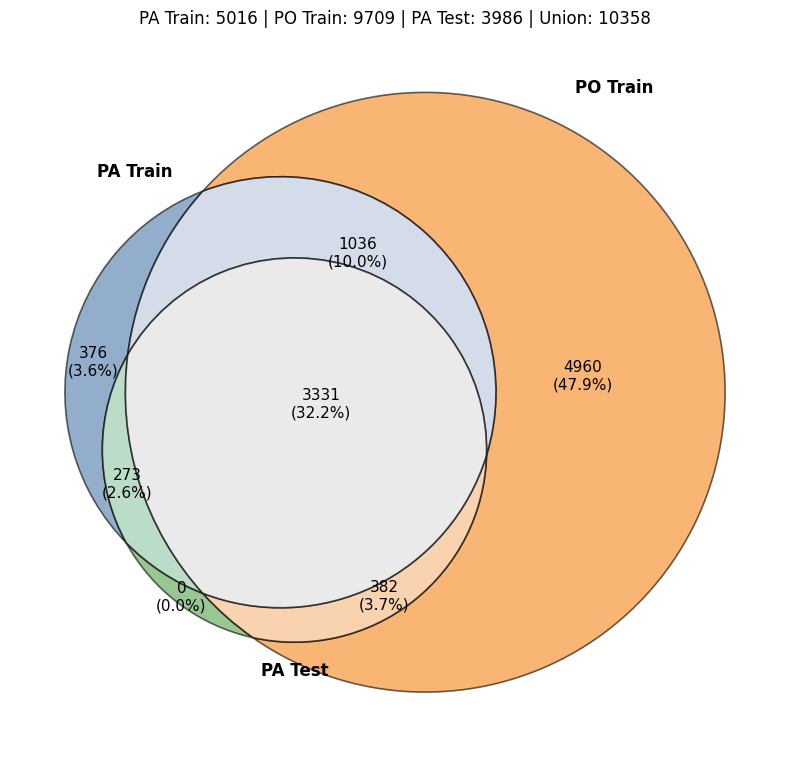

In [31]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

PA_tr, PO_tr, PA_te = set(species_pa_train), set(species_po_train), set(species_pa_test)
colors = ("#4C78A8", "#F58518", "#54A24B")  # PA train, PO train, PA test

plt.figure(figsize=(8,8))
v = venn3((PA_tr, PO_tr, PA_te), set_labels=("PA Train","PO Train","PA Test"))
for s in ("100","010","110","001","101","011","111"):
    p = v.get_patch_by_id(s)
    if p: p.set_facecolor({"100":colors[0],"010":colors[1],"001":colors[2],
                           "110":"#B8C5DC","101":"#8FC6A1","011":"#F5B57B","111":"#DDDDDD"}[s]); p.set_alpha(0.6); p.set_edgecolor("black"); p.set_linewidth(1.2)
for lbl in v.set_labels: 
    if lbl: lbl.set_fontsize(12); lbl.set_fontweight("bold")
total = len(PA_tr|PO_tr|PA_te)
counts = {"100":len(PA_tr-PO_tr-PA_te),"010":len(PO_tr-PA_tr-PA_te),"001":len(PA_te-PA_tr-PO_tr),
          "110":len((PA_tr&PO_tr)-PA_te),"101":len((PA_tr&PA_te)-PO_tr),"011":len((PO_tr&PA_te)-PA_tr),"111":len(PA_tr&PO_tr&PA_te)}
for k,n in counts.items():
    t = v.get_label_by_id(k)
    if t: t.set_text(f"{n}\n({(n/total*100 if total else 0):.1f}%)"); t.set_fontsize(11)
plt.title(f"PA Train: {len(PA_tr)} | PO Train: {len(PO_tr)} | PA Test: {len(PA_te)} | Union: {total}", pad=10)
plt.tight_layout(); plt.show()
